In [1]:
import torch
import torch.nn as nn

In [6]:
# 定义模型
class SimpleLinearRegressionModel(nn.Module):
    def __init__(self):
        # 调用父类的模型
        super(SimpleLinearRegressionModel, self).__init__()
        self.linear = nn.Linear(1, 1)

    # 通过传递 横轴x 内容，预测 纵轴y 上数据
    def forward(self, x):
        return self.linear(x)


In [3]:
# 自定义训练数据，定义 横轴、纵轴 数据
# y = 2x + b + noise
x_data = torch.tensor([[0.7], [1.4], [2.2], [3.5], [5.7], [8.1]])
y_data = torch.tensor([[1.6], [2.4], [4.6], [5.2], [11.8], [15.8]])


In [7]:
# 定义模型
models = SimpleLinearRegressionModel()
# 创建损失函数
credits = nn.MSELoss()
# 定义优化器
optimizer = torch.optim.SGD(models.parameters(), lr = 0.01)

In [8]:
# 训练前参数
for param in models.parameters():
    print(f'训练前模型中数据有：{param}')

训练前模型中数据有：Parameter containing:
tensor([[0.4628]], requires_grad=True)
训练前模型中数据有：Parameter containing:
tensor([0.6459], requires_grad=True)


In [24]:
# 开始训练
# 定义损失值数组，保存每轮损失值
losses = []
# 训练指定次数
for epoch in range(200):
    # 将 x 值传给模型得到预测值
    y_pred = models(x_data)
    # 通过损失函数计算损失值, 损失值是两个值作比较得出来
    loss = credits(y_pred, y_data)

    # 反向传播梯度求导
    # 清除每批的梯度值
    optimizer.zero_grad()
    # 反向传播
    loss.backward()
    # 预测下一次值
    optimizer.step()

    # 保存损失值
    losses.append(loss.item())


    # 打印每批训练参数
    if epoch % 20 == 0:
        print(f'批次Epoch【{epoch} / 100】， Loss：[{loss.item():.3f}]')


# 训练后参数
for param in models.parameters():
    print(f'训练后模型中数据有：{param}')



批次Epoch【0 / 100】， Loss：[0.541]
批次Epoch【20 / 100】， Loss：[0.541]
批次Epoch【40 / 100】， Loss：[0.541]
批次Epoch【60 / 100】， Loss：[0.541]
批次Epoch【80 / 100】， Loss：[0.541]
批次Epoch【100 / 100】， Loss：[0.541]
批次Epoch【120 / 100】， Loss：[0.541]
批次Epoch【140 / 100】， Loss：[0.541]
批次Epoch【160 / 100】， Loss：[0.541]
批次Epoch【180 / 100】， Loss：[0.541]
训练后模型中数据有：Parameter containing:
tensor([[1.9807]], requires_grad=True)
训练后模型中数据有：Parameter containing:
tensor([-0.2298], requires_grad=True)


Text(0, 0.5, 'Loss')

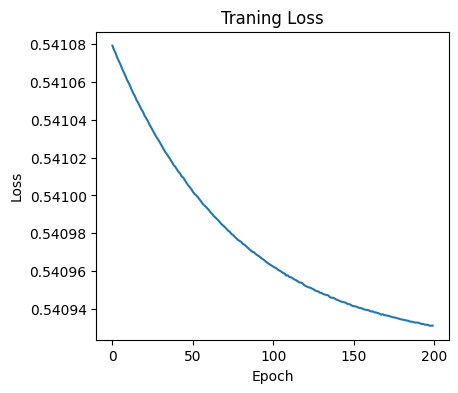

In [23]:
# 绘制模型图
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Traning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

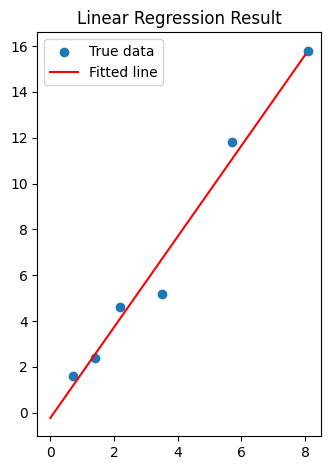

In [26]:
plt.subplot(1, 2, 1)
plt.scatter(x_data.numpy(), y_data.numpy(), label= 'True data')

x_plot = torch.linspace(0, 8, 100)
x_plot = x_plot.reshape(-1, 1)

y_plot = models(x_plot).detach()

plt.plot(x_plot.numpy(), y_plot.numpy(), 'r-', label = 'Fitted line')
plt.legend()
plt.title('Linear Regression Result')
plt.tight_layout()
plt.show()